# G4Discovery Parameter Exploration

Sweeps pqsfinder score and G4Hunter score thresholds to understand how G4Discovery
quality filtering affects agreement with rG4detector.

**Goal:** identify which threshold combination best separates signal from noise
before the fixed-subset analysis in **g4_intersect_exploration.ipynb**.

## 1. Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", font="Arial")

from importlib import reload
import sys; sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/secondrna/workflow/")
from utils import g4_analysis_lib as lib
from IPython.display import display, Markdown

SAMPLE = "gencode.v47"
os.chdir("/mnt/cbib/LNClassifier/paper/secondrna")
print("Imports OK")

Imports OK


## 2. Data Loading

In [ ]:
INTERSECT_PATH  = f"results/{SAMPLE}/{SAMPLE}.g4Discovery.rG4detector.intersect.bed"
PEAKS_PATH      = f"results/{SAMPLE}/rg4detector/{SAMPLE}.rG4detector.peaks.bed"
CODING_ANN_PATH = f"results/{SAMPLE}/{SAMPLE}.coding_annotation.tsv"
LENGTH_ANN_PATH = f"results/{SAMPLE}/{SAMPLE}.transcript_lengths.tsv"

intersect  = lib.load_intersect(INTERSECT_PATH)
peaks      = lib.load_peaks(PEAKS_PATH)
coding_ann = lib.load_coding_annotation(CODING_ANN_PATH)
length_ann = lib.load_length_annotation(LENGTH_ANN_PATH)

union_df = lib.build_union_df(intersect, peaks)
union_df = lib.annotate_union(union_df, coding_ann, length_ann)

assert "real"      in union_df.columns
assert "tx_len_nt" in union_df.columns
print(f"union_df: {union_df.shape}  types: {union_df['type'].value_counts().to_dict()}")

/mnt/cbib/LNClassifier/paper/secondrna/workflow/utils/g4_analysis_lib.py:122: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  union["overlaps"] = union["overlaps"].fillna(False).astype(bool)


union_df: (61850, 19)  types: {'RG4D only': 30570, 'G4D only': 16773, 'both': 14507}


## 3. Baseline: full union (no threshold)

Stats for all motifs before any G4D quality filter, as a reference point.

In [ ]:
baseline_agg  = lib.compute_aggregate_stats(union_df)
baseline_test = lib.run_statistical_tests(union_df, coding_ann, length_ann)
print("Baseline (no threshold):")
display(pd.DataFrame([baseline_agg]).T.rename(columns={0: "value"}))
display(pd.DataFrame([baseline_test]).T.rename(columns={0: "value"}))

Baseline (no threshold):


,value
total,61850.000000
both,14507.000000
g4d_only,16773.000000
rg4d_only,30570.000000
g4d_total,31280.000000
rg4d_total,45077.000000
g4d_overlap_frac,0.463779
rg4d_overlap_frac,0.321827
n_g4d_in_pc,11882.000000
n_g4d_in_lncrna,3262.000000


,value
chi2,1.322068e+03
p_chi2,1.809832e-289
cramers_v,1.088162e-01
u_stat,1.612788e+09
p_mwu,1.540661e-244
vda,5.366587e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


## 4. Threshold Sweep

In [ ]:
threshold_subsets = lib.build_threshold_subsets(union_df)

sweep_results = {}
for spec, sdf in threshold_subsets:
    agg  = lib.compute_aggregate_stats(sdf)
    test = lib.run_statistical_tests(sdf, coding_ann, length_ann)
    sweep_results[spec.name] = {"spec": spec, "agg_stats": agg, "test_results": test}
    print(f"{spec.label:30s}  {len(sdf):6,} motifs  "
          f"overlap={agg['g4d_overlap_frac']:.3f}  "
          f"cramers_v={test['cramers_v']:.4f}  vda={test['vda']:.4f}  "
          f"in_pc={agg['n_g4d_in_pc']:,}  in_lncrna={agg['n_g4d_in_lncrna']:,}")

G4D pqs≥30 & G4H≥1.0            61,850 motifs  overlap=0.464  cramers_v=0.1088  vda=0.5367  in_pc=11,882  in_lncrna=3,262
G4D pqs≥30 & G4H≥1.2            59,737 motifs  overlap=0.496  cramers_v=0.1059  vda=0.5353  in_pc=10,976  in_lncrna=3,083
G4D pqs≥30 & G4H≥1.5            54,696 motifs  overlap=0.581  cramers_v=0.1006  vda=0.5327  in_pc=8,964  in_lncrna=2,542
G4D pqs≥40 & G4H≥1.0            59,333 motifs  overlap=0.495  cramers_v=0.1050  vda=0.5350  in_pc=10,813  in_lncrna=3,051
G4D pqs≥40 & G4H≥1.2            57,372 motifs  overlap=0.530  cramers_v=0.1019  vda=0.5336  in_pc=9,971  in_lncrna=2,887
G4D pqs≥40 & G4H≥1.5            53,114 motifs  overlap=0.612  cramers_v=0.0972  vda=0.5313  in_pc=8,310  in_lncrna=2,413


## 5. Comparison Table

In [ ]:
comp_df = lib.compare_results(sweep_results)
display(
    comp_df[[
        "total_motifs", "g4d_total", "both", "g4d_overlap_frac",
        "n_g4d_in_pc", "n_g4d_in_lncrna", "frac_g4d_in_annotated",
        "cramers_v", "p_chi2", "vda", "p_mwu",
        "median_coding_per_kb", "median_lncrna_per_kb",
    ]]
    .style
    .format({
        "total_motifs": "{:,}", "g4d_total": "{:,}", "both": "{:,}",
        "g4d_overlap_frac": "{:.3f}",
        "n_g4d_in_pc": "{:,}", "n_g4d_in_lncrna": "{:,}",
        "frac_g4d_in_annotated": "{:.3f}",
        "cramers_v": "{:.4f}", "p_chi2": "{:.2e}",
        "vda": "{:.4f}", "p_mwu": "{:.2e}",
        "median_coding_per_kb": "{:.4f}", "median_lncrna_per_kb": "{:.4f}",
    })
    .background_gradient(subset=["cramers_v", "vda", "g4d_overlap_frac", "frac_g4d_in_annotated"], cmap="YlOrRd")
)

,total_motifs,g4d_total,both,g4d_overlap_frac,n_g4d_in_pc,n_g4d_in_lncrna,frac_g4d_in_annotated,cramers_v,p_chi2,vda,p_mwu,median_coding_per_kb,median_lncrna_per_kb
subset,,,,,,,,,,,,,
G4D pqs≥30 & G4H≥1.0,"61,850","31,280","14,507",0.464,"11,882","3,262",0.484,0.1088,1.81e-289,0.5367,1.54e-244,0.0000,0.0000
G4D pqs≥30 & G4H≥1.2,"59,737","29,167","14,459",0.496,"10,976","3,083",0.482,0.1059,2.70e-274,0.5353,9.49e-232,0.0000,0.0000
G4D pqs≥30 & G4H≥1.5,"54,696","24,126","14,021",0.581,"8,964","2,542",0.477,0.1006,1.00e-247,0.5327,5.24e-210,0.0000,0.0000
G4D pqs≥40 & G4H≥1.0,"59,333","28,763","14,249",0.495,"10,813","3,051",0.482,0.1050,1.36e-269,0.5350,4.25e-228,0.0000,0.0000
G4D pqs≥40 & G4H≥1.2,"57,372","26,802","14,202",0.530,"9,971","2,887",0.480,0.1019,5.01e-254,0.5336,5.34e-215,0.0000,0.0000
G4D pqs≥40 & G4H≥1.5,"53,114","22,544","13,796",0.612,"8,310","2,413",0.476,0.0972,2.99e-231,0.5313,2.36e-196,0.0000,0.0000


## 6. Heatmaps — metrics across parameter grid

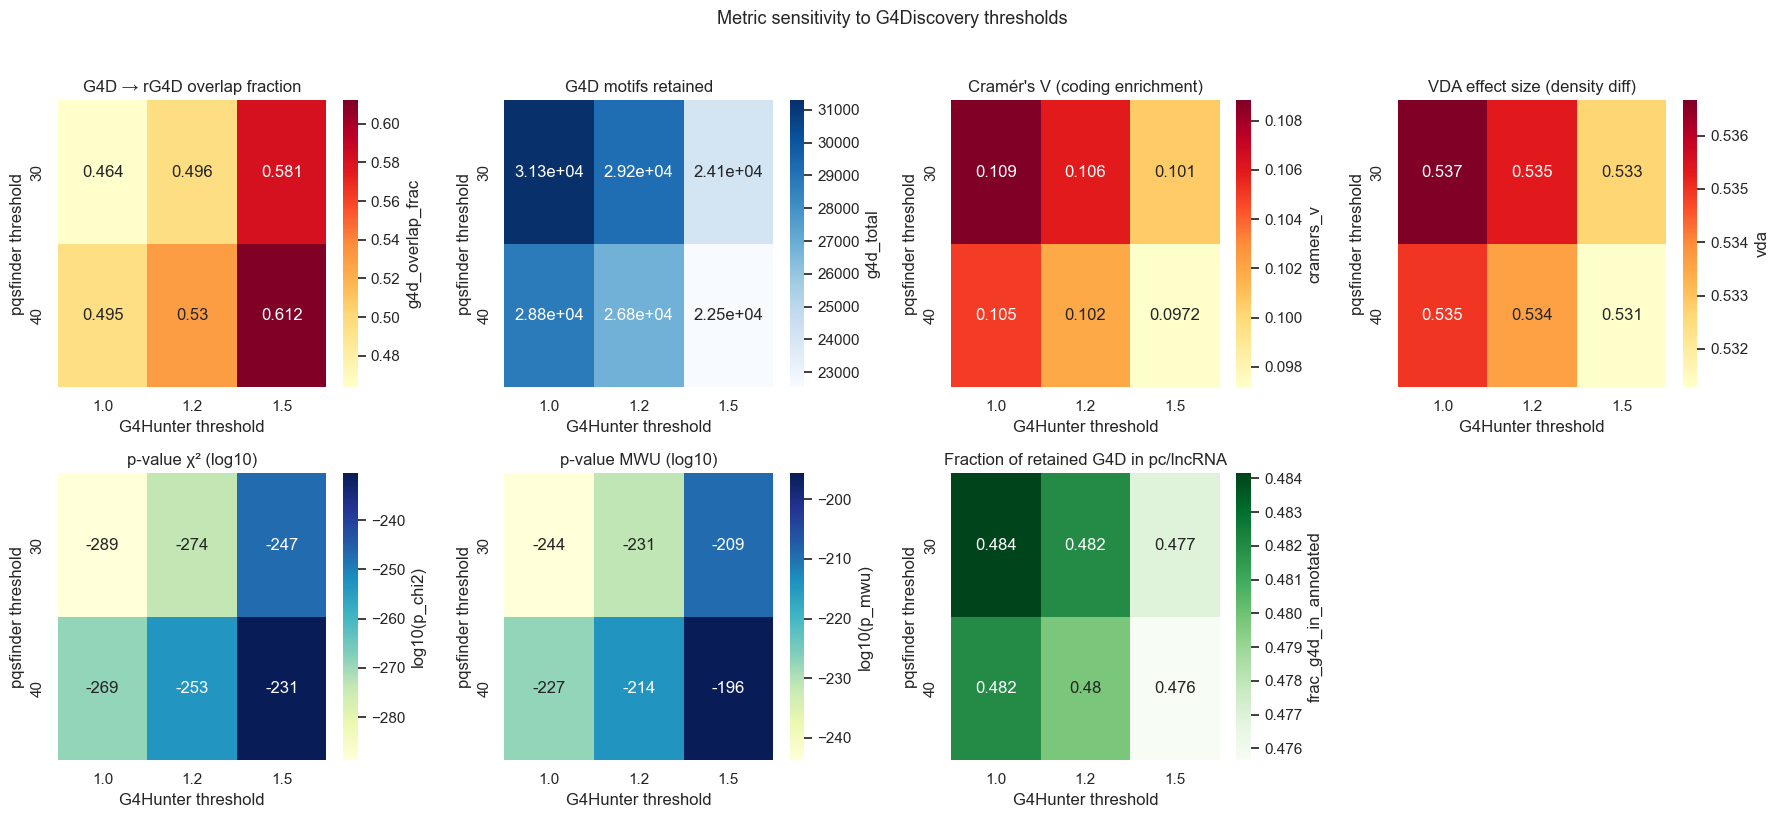

In [ ]:
# Reshape comp_df into (pqs_th × g4h_th) grids for each metric
rows = []
for name, res in sweep_results.items():
    parts = name.split("_")  # pqs{P}_g4h{H}
    pqs = float(parts[0].replace("pqs", ""))
    g4h = float(parts[1].replace("g4h", ""))
    agg  = res["agg_stats"]
    test = res["test_results"]
    rows.append({
        "pqs_th": pqs, "g4h_th": g4h,
        "g4d_total": agg["g4d_total"],
        "g4d_overlap_frac": agg["g4d_overlap_frac"],
        "cramers_v": test["cramers_v"],
        "p_chi2": test["p_chi2"],
        "vda": test["vda"],
        "p_mwu": test["p_mwu"],
        "median_coding_per_kb": test["median_coding_per_kb"],
        "median_lncrna_per_kb": test["median_lncrna_per_kb"],
        "n_g4d_in_pc": agg["n_g4d_in_pc"],
        "n_g4d_in_lncrna": agg["n_g4d_in_lncrna"],
        "frac_g4d_in_annotated": agg["frac_g4d_in_annotated"],
    })
grid_df = pd.DataFrame(rows)

metrics = [
    ("g4d_overlap_frac",      "G4D → rG4D overlap fraction",         "YlOrRd", False),
    ("g4d_total",             "G4D motifs retained",                   "Blues",  False),
    ("cramers_v",             "Cramér's V (coding enrichment)",        "YlOrRd", False),
    ("vda",                   "VDA effect size (density diff)",        "YlOrRd", False),
    ("p_chi2",                "p-value χ² (log10)",                    "YlGnBu", True),
    ("p_mwu",                 "p-value MWU (log10)",                   "YlGnBu", True),
    ("frac_g4d_in_annotated", "Fraction of retained G4D in pc/lncRNA","Greens", False),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, (col, title, cmap, log_scale) in zip(axes.flat, metrics):
    pivot = grid_df.pivot(index="pqs_th", columns="g4h_th", values=col)
    vals  = np.log10(pivot.values.astype(float)) if log_scale else pivot.values.astype(float)
    label = f"log10({col})" if log_scale else col
    sns.heatmap(
        vals, ax=ax,
        xticklabels=[f"{v:.1f}" for v in pivot.columns],
        yticklabels=[str(int(v)) for v in pivot.index],
        annot=True, fmt=".3g", cmap=cmap, cbar_kws={"label": label},
    )
    ax.set_xlabel("G4Hunter threshold")
    ax.set_ylabel("pqsfinder threshold")
    ax.set_title(title)

axes.flat[-1].set_visible(False)
plt.suptitle("Metric sensitivity to G4Discovery thresholds", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

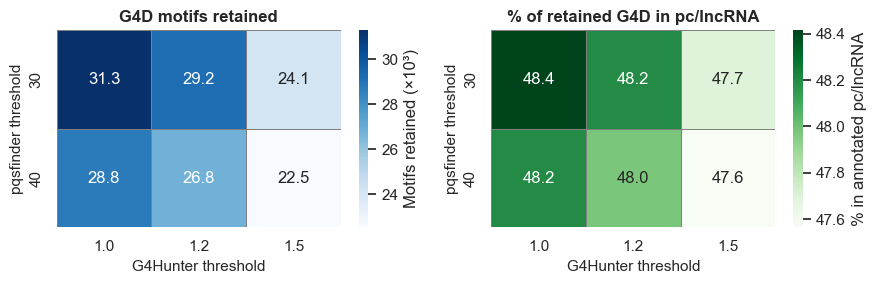


Motifs retained (×10³):


g4h_th,1.000000,1.200000,1.500000
pqs_th,,,
30.000000,31.300000,29.200000,24.100000
40.000000,28.800000,26.800000,22.500000



Fraction in annotated pc/lncRNA (%):


g4h_th,1.000000,1.200000,1.500000
pqs_th,,,
30.000000,48.400000,48.200000,47.700000
40.000000,48.200000,48.000000,47.600000


In [ ]:
# Focused heatmaps: motifs retained and fraction in annotated transcripts, side by side
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9, 3))

pivot = grid_df.pivot(index="pqs_th", columns="g4h_th", values="g4d_total")
vals = pivot.values.astype(float) / 1000

sns.heatmap(
    vals, ax=ax,
    xticklabels=[f"{v:.1f}" for v in pivot.columns],
    yticklabels=[f"{int(v)}" for v in pivot.index],
    annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "Motifs retained (×10³)"},
    linewidths=0.5, linecolor="gray"
)
ax.set_xlabel("G4Hunter threshold", fontsize=11)
ax.set_ylabel("pqsfinder threshold", fontsize=11)
ax.set_title("G4D motifs retained", fontsize=12, fontweight="bold")

pivot2 = grid_df.pivot(index="pqs_th", columns="g4h_th", values="frac_g4d_in_annotated")
vals2 = pivot2.values.astype(float) * 100

sns.heatmap(
    vals2, ax=ax2,
    xticklabels=[f"{v:.1f}" for v in pivot2.columns],
    yticklabels=[f"{int(v)}" for v in pivot2.index],
    annot=True, fmt=".1f", cmap="Greens", cbar_kws={"label": "% in annotated pc/lncRNA"},
    linewidths=0.5, linecolor="gray"
)
ax2.set_xlabel("G4Hunter threshold", fontsize=11)
ax2.set_ylabel("pqsfinder threshold", fontsize=11)
ax2.set_title("% of retained G4D in pc/lncRNA", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nMotifs retained (×10³):")
display(
    (pivot / 1000).round(1)
    .style.background_gradient(cmap="Blues")
)
print(f"\nFraction in annotated pc/lncRNA (%):")
display(
    (pivot2 * 100).round(1)
    .style.background_gradient(cmap="Greens")
)

In [ ]:
grid_df

,pqs_th,g4h_th,g4d_total,g4d_overlap_frac,cramers_v,p_chi2,vda,p_mwu,median_coding_per_kb,median_lncrna_per_kb,n_g4d_in_pc,n_g4d_in_lncrna,frac_g4d_in_annotated
0,30.0,1.0,31280,0.463779,0.108816,1.809832e-289,0.536659,1.540661e-244,0.0,0.0,11882,3262,0.484143
1,30.0,1.2,29167,0.495731,0.105904,2.696470e-274,0.535330,9.485949e-232,0.0,0.0,10976,3083,0.482017
2,30.0,1.5,24126,0.581157,0.100601,1.002688e-247,0.532680,5.236073e-210,0.0,0.0,8964,2542,0.476913
3,40.0,1.0,28763,0.495393,0.104985,1.356445e-269,0.534967,4.252799e-228,0.0,0.0,10813,3051,0.482008
4,40.0,1.2,26802,0.529886,0.101884,5.013073e-254,0.533593,5.339230e-215,0.0,0.0,9971,2887,0.479740
5,40.0,1.5,22544,0.611959,0.097169,2.987405e-231,0.531279,2.359498e-196,0.0,0.0,8310,2413,0.475648


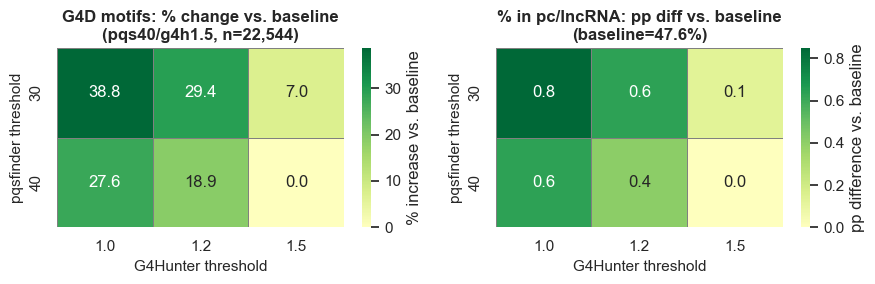


Percentage increase relative to baseline (pqs40/g4h1.5):


g4h_th,1.000000,1.200000,1.500000
pqs_th,,,
30.000000,38.800000,29.400000,7.000000
40.000000,27.600000,18.900000,0.000000



Percentage-point diff in annotated fraction vs. baseline:


g4h_th,1.000000,1.200000,1.500000
pqs_th,,,
30.000000,0.850000,0.640000,0.130000
40.000000,0.640000,0.410000,0.000000


In [ ]:
# Calculate percentage increase relative to the default baseline (pqs40/g4h1.5)

DEFAULT_PQS_TH = 40
DEFAULT_G4H_TH = 1.5

baseline_g4d = grid_df.loc[
    (grid_df["pqs_th"] == DEFAULT_PQS_TH) & (grid_df["g4h_th"] == DEFAULT_G4H_TH),
    "g4d_total"
].values[0]

baseline_frac = grid_df.loc[
    (grid_df["pqs_th"] == DEFAULT_PQS_TH) & (grid_df["g4h_th"] == DEFAULT_G4H_TH),
    "frac_g4d_in_annotated"
].values[0]

grid_df_pct = grid_df.copy()
grid_df_pct["pct_increase"] = ((grid_df_pct["g4d_total"] - baseline_g4d) / baseline_g4d * 100)
grid_df_pct["pct_annotated_diff"] = (grid_df_pct["frac_g4d_in_annotated"] - baseline_frac) * 100

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9, 3))

pivot_pct = grid_df_pct.pivot(index="pqs_th", columns="g4h_th", values="pct_increase")

sns.heatmap(
    pivot_pct, ax=ax,
    xticklabels=[f"{v:.1f}" for v in pivot_pct.columns],
    yticklabels=[f"{int(v)}" for v in pivot_pct.index],
    annot=True, fmt=".1f", cmap="RdYlGn", center=0,
    cbar_kws={"label": f"% increase vs. baseline"},
    linewidths=0.5, linecolor="gray"
)
ax.set_xlabel("G4Hunter threshold", fontsize=11)
ax.set_ylabel("pqsfinder threshold", fontsize=11)
ax.set_title(f"G4D motifs: % change vs. baseline\n(pqs{DEFAULT_PQS_TH}/g4h{DEFAULT_G4H_TH}, n={baseline_g4d:,})",
             fontsize=12, fontweight="bold")

pivot_ann_diff = grid_df_pct.pivot(index="pqs_th", columns="g4h_th", values="pct_annotated_diff")

sns.heatmap(
    pivot_ann_diff, ax=ax2,
    xticklabels=[f"{v:.1f}" for v in pivot_ann_diff.columns],
    yticklabels=[f"{int(v)}" for v in pivot_ann_diff.index],
    annot=True, fmt=".1f", cmap="RdYlGn", center=0,
    cbar_kws={"label": "pp difference vs. baseline"},
    linewidths=0.5, linecolor="gray"
)
ax2.set_xlabel("G4Hunter threshold", fontsize=11)
ax2.set_ylabel("pqsfinder threshold", fontsize=11)
ax2.set_title(f"% in pc/lncRNA: pp diff vs. baseline\n(baseline={baseline_frac*100:.1f}%)",
              fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nPercentage increase relative to baseline (pqs{DEFAULT_PQS_TH}/g4h{DEFAULT_G4H_TH}):")
display(pivot_pct.round(1).style.background_gradient(cmap="RdYlGn"))
print(f"\nPercentage-point diff in annotated fraction vs. baseline:")
display(pivot_ann_diff.round(2).style.background_gradient(cmap="RdYlGn"))

## 7. Score distributions by coding class with threshold markers

Each score is shown separately for protein-coding and non-coding G4D motifs.
Vertical lines mark every threshold value; the area to the right of each line
is what that threshold retains.

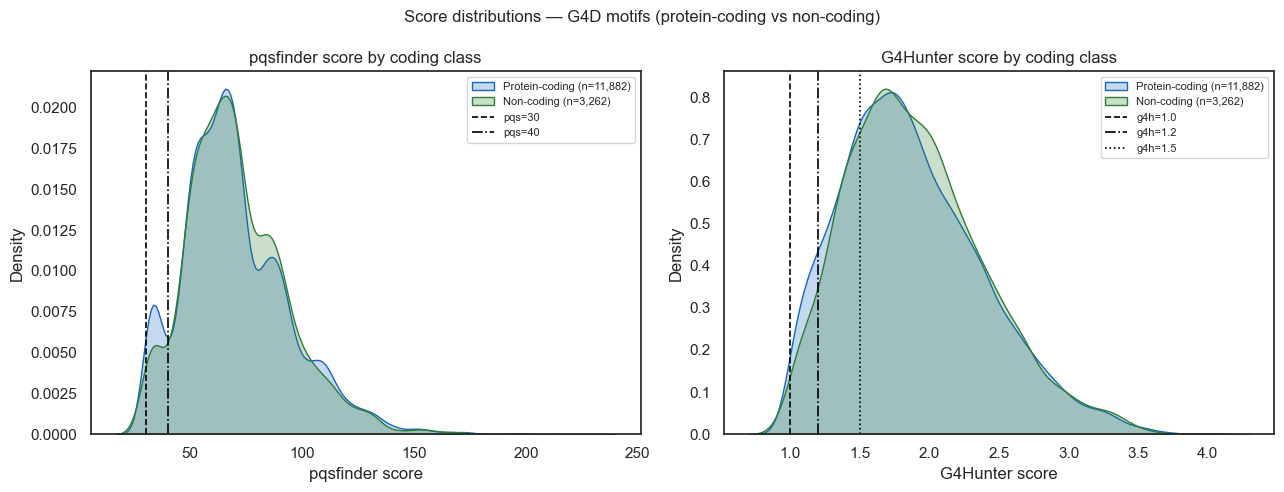

In [ ]:
g4d_all = union_df[union_df["type"] != "RG4D only"].copy()
g4d_all = g4d_all[g4d_all["g4HunterScore"] > 0]
g4d_all["coding_class"] = g4d_all["real"].map({True: "Protein-coding", False: "Non-coding"})
g4d_ann = g4d_all.dropna(subset=["coding_class"])

_CLASS_COLORS = {"Protein-coding": "#1565C0", "Non-coding": "#2E7D32"}
_PQS_CUTS = lib._PQS_THRESHOLDS
_G4H_CUTS = lib._G4H_THRESHOLDS
_CUT_STYLES = ["--", "-.", ":"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── pqsfinder score ──────────────────────────────────────────────────────────
ax = axes[0]
for cls, color in _CLASS_COLORS.items():
    vals = g4d_ann.loc[g4d_ann["coding_class"] == cls, "pqsfinder_score"]
    sns.kdeplot(vals, ax=ax, label=f"{cls} (n={len(vals):,})",
                color=color, fill=True, alpha=0.25)
for th, ls in zip(_PQS_CUTS, _CUT_STYLES):
    ax.axvline(th, color="black", linestyle=ls, linewidth=1.2, label=f"pqs={th}")
ax.set_xlabel("pqsfinder score")
ax.set_ylabel("Density")
ax.set_title("pqsfinder score by coding class")
ax.legend(fontsize=8)

# ── G4Hunter score ───────────────────────────────────────────────────────────
ax = axes[1]
for cls, color in _CLASS_COLORS.items():
    vals = g4d_ann.loc[g4d_ann["coding_class"] == cls, "g4HunterScore"]
    sns.kdeplot(vals, ax=ax, label=f"{cls} (n={len(vals):,})",
                color=color, fill=True, alpha=0.25)
for th, ls in zip(_G4H_CUTS, _CUT_STYLES):
    ax.axvline(th, color="black", linestyle=ls, linewidth=1.2, label=f"g4h={th}")
ax.set_xlabel("G4Hunter score")
ax.set_ylabel("Density")
ax.set_title("G4Hunter score by coding class")
ax.legend(fontsize=8)

plt.suptitle("Score distributions — G4D motifs (protein-coding vs non-coding)", fontsize=12)
plt.tight_layout(); plt.show()

## 8. Overlap fraction vs. retained motifs (Pareto view)

Scatter each threshold combination by (motifs retained, overlap fraction) to visualise the quality–quantity trade-off.

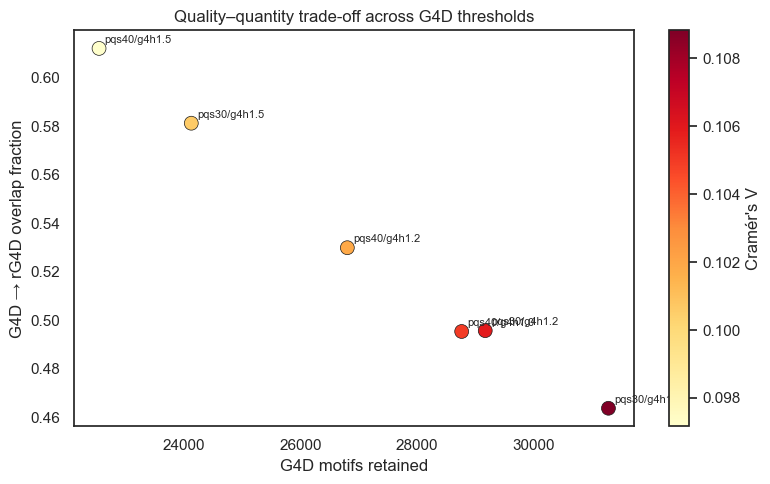

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    grid_df["g4d_total"],
    grid_df["g4d_overlap_frac"],
    c=grid_df["cramers_v"], cmap="YlOrRd", s=100, edgecolors="k", linewidths=0.5,
)
for _, row in grid_df.iterrows():
    ax.annotate(
        f"pqs{int(row['pqs_th'])}/g4h{row['g4h_th']:.1f}",
        xy=(row["g4d_total"], row["g4d_overlap_frac"]),
        xytext=(4, 4), textcoords="offset points", fontsize=8,
    )
plt.colorbar(scatter, ax=ax, label="Cramér's V")
ax.set_xlabel("G4D motifs retained")
ax.set_ylabel("G4D → rG4D overlap fraction")
ax.set_title("Quality–quantity trade-off across G4D thresholds")
plt.tight_layout(); plt.show()

## 9. Conclusion

Review the heatmaps and scatter above, then record the chosen thresholds.
Update `PQS_TH` and `G4H_TH` in **g4_intersect_exploration.ipynb** accordingly.

In [ ]:
# Record your choice here for reproducibility
CHOSEN_PQS_TH = 40
CHOSEN_G4H_TH = 1.2

chosen_name = f"pqs{CHOSEN_PQS_TH}_g4h{CHOSEN_G4H_TH}"
chosen = sweep_results[chosen_name]
print(f"Chosen thresholds: pqs≥{CHOSEN_PQS_TH}, G4H≥{CHOSEN_G4H_TH}")
print(f"  G4D motifs retained : {chosen['agg_stats']['g4d_total']:,}")
print(f"  Overlap fraction    : {chosen['agg_stats']['g4d_overlap_frac']:.3f}")
print(f"  Cramér's V          : {chosen['test_results']['cramers_v']:.4f}")
print(f"  VDA                 : {chosen['test_results']['vda']:.4f}")

Chosen thresholds: pqs≥40, G4H≥1.2
  G4D motifs retained : 26,802
  Overlap fraction    : 0.530
  Cramér's V          : 0.1019
  VDA                 : 0.5336
